In [1]:
#Iris Classification

In [2]:
#Load dataset
import pandas as pd

df = pd.read_csv("..\data\Iris.csv")

In [3]:
#Exploratory Data Analysis
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.shape

(150, 6)

### Observation

- The Iris dataset was loaded successfully using Pandas.
- The dataset contains 150 rows and 6 columns.
- The columns include Id, four flower measurements, and the Species column.
- The first five rows were displayed to verify that the data loaded correctly.

In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [7]:
df.isnull().sum()

Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

In [8]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [9]:
df["Species"].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [10]:
df["Species"].value_counts()

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

### Observation

- The dataset contains 6 columns: Id, four flower measurement features, and the Species column.
- The numerical feature columns are stored as numeric data types, while Species is a categorical column.
- No missing values were found in the dataset.
- There are three flower species: Iris-setosa, Iris-versicolor, and Iris-virginica.
- Each species contains 50 samples, making the dataset balanced and suitable for classification.

In [11]:
#Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

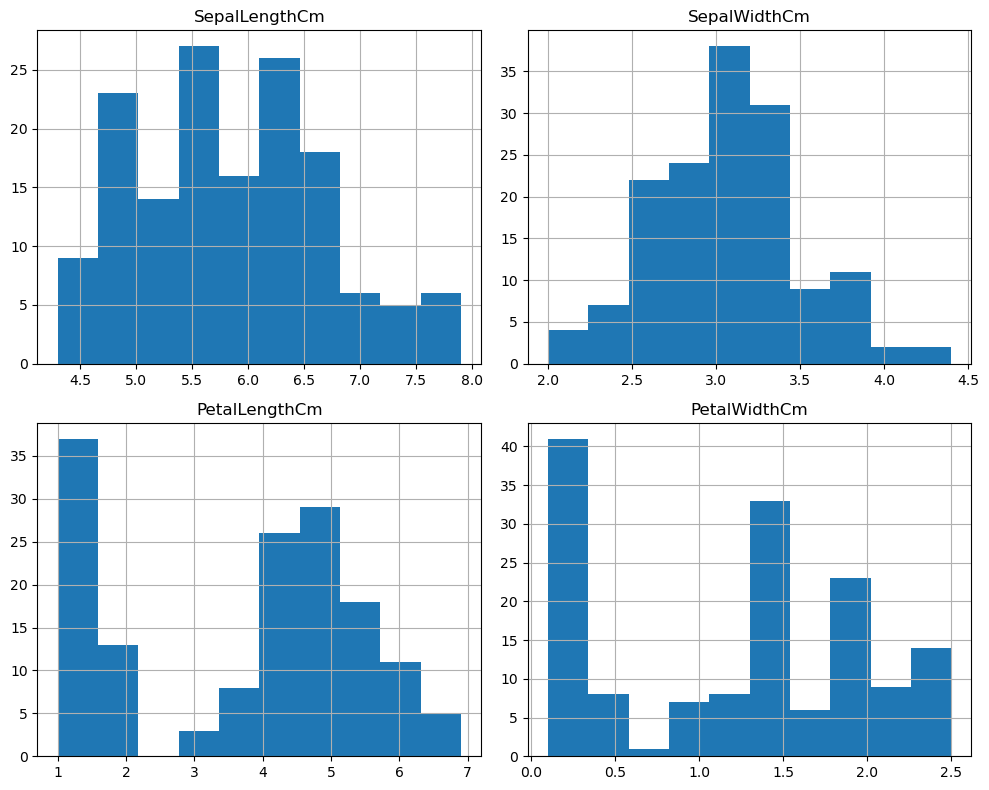

In [12]:
df.drop(columns=["Id"]).hist(figsize=(10,8))
plt.tight_layout()
plt.savefig("../images/histogram.png", dpi=300)
plt.show()

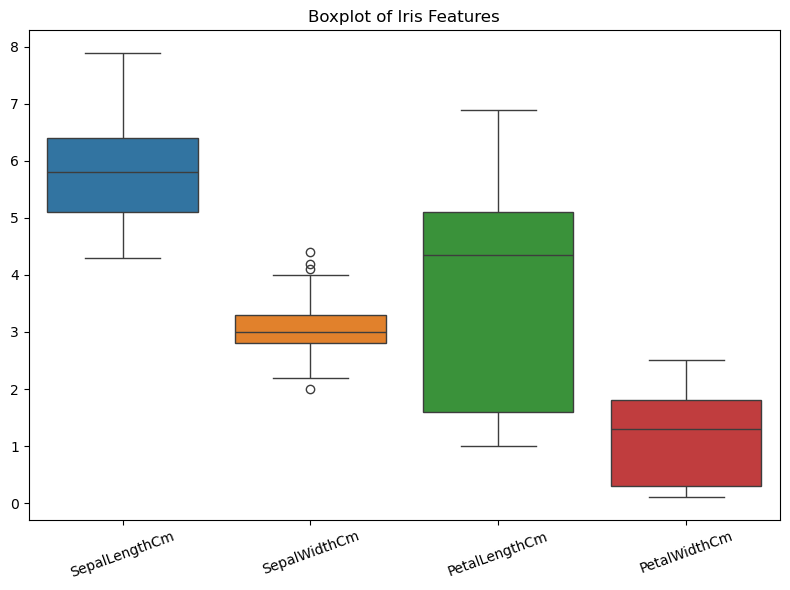

In [13]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df.drop(columns=["Id", "Species"]))
plt.title("Boxplot of Iris Features")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../images/boxplot.png", dpi=300, bbox_inches="tight")
plt.show()

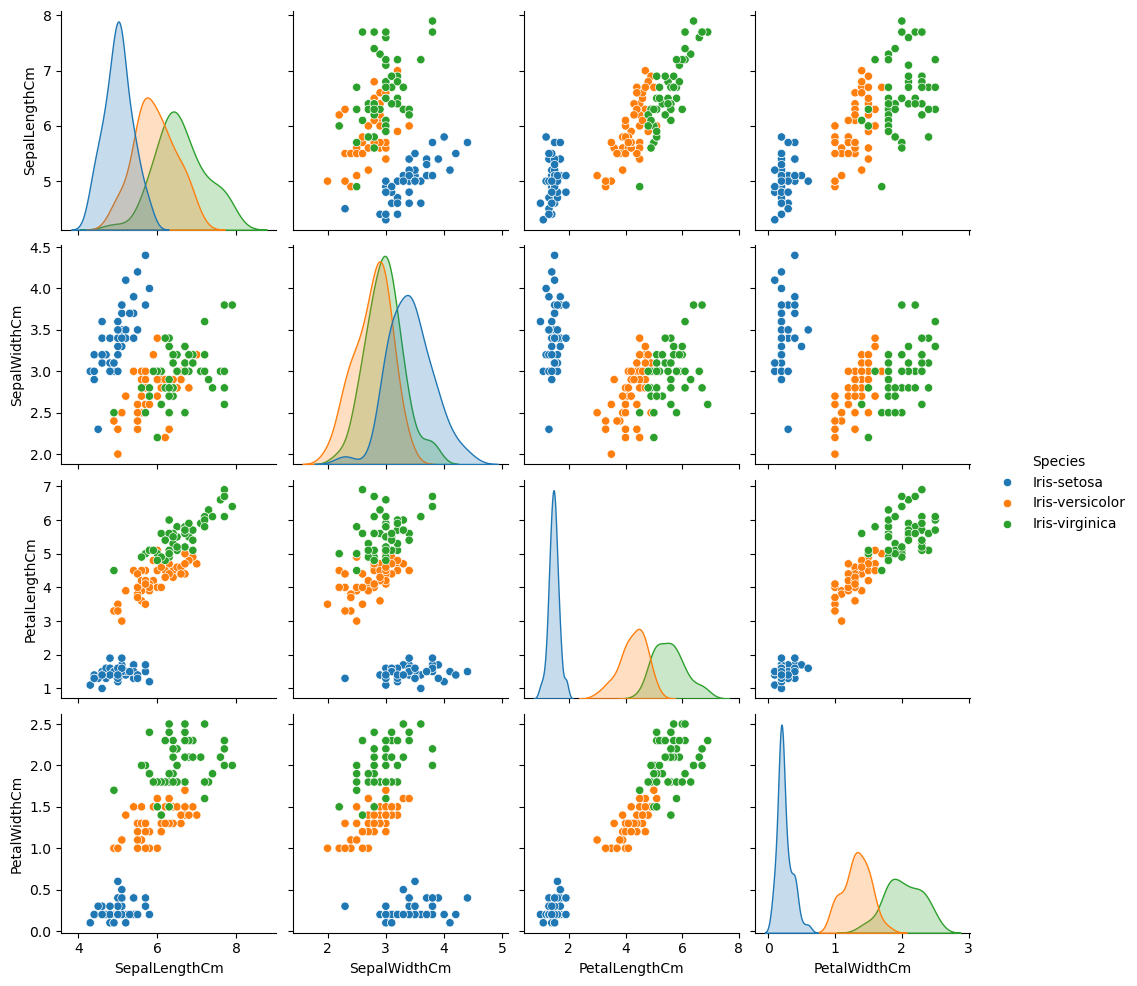

In [14]:
pair = sns.pairplot(df.drop(columns="Id"), hue="Species")
pair.figure.savefig("../images/pairplot.png", dpi=300, bbox_inches="tight")
plt.show()

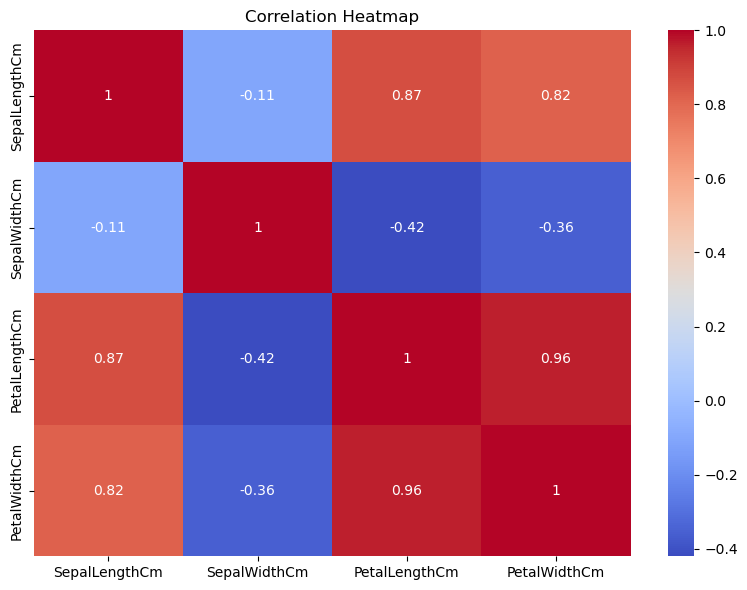

In [15]:
plt.figure(figsize=(8,6))

corr = df.drop(columns=["Id"]).select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig("../images/heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- The histograms show the distribution of each flower measurement.
- The boxplots indicate that the dataset has very few outliers.
- The pairplot clearly shows that *Iris-setosa* is well separated from the other two species, while *Iris-versicolor* and *Iris-virginica* have slight overlap.
- The correlation heatmap shows that petal length and petal width are strongly positively correlated, making them important features for classification.

In [16]:
#Prepare Features (X) and Target (y)
# Features (Input)
X = df.drop(columns=["Id", "Species"])

# Target (Output)
y = df["Species"]

In [17]:
X.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [18]:
y.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Species, dtype: object

In [19]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (150, 4)
Target shape: (150,)


### Observation

The dataset was successfully divided into features (`X`) and the target (`y`). The `Id` column was removed because it is only an identifier and does not contribute to predicting the flower species. The feature set contains four numerical measurements, while the target contains the corresponding species labels for all 150 flower samples.

In [20]:
#Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [21]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (120, 4)
Testing features: (30, 4)
Training labels: (120,)
Testing labels: (30,)


### Observation

The dataset was successfully divided into training and testing sets using an 80:20 ratio. The training set contains 120 flower samples and is used to train the machine learning model, while the testing set contains 30 unseen samples to evaluate the model's performance. A fixed `random_state` was used to ensure that the data split remains consistent and reproducible.

In [22]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)

In [23]:
knn.fit(X_train, y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


### Observation

A K-Nearest Neighbors (KNN) classifier was created with `k = 3` and trained using the training dataset. During the training process, the model learned the relationship between the flower measurements and their corresponding species. The trained model is now ready to predict the species of unseen flower samples.

In [24]:
# Predict the species of the test data
y_pred = knn.predict(X_test)
y_pred[:10]

array(['Iris-versicolor', 'Iris-setosa', 'Iris-virginica',
       'Iris-versicolor', 'Iris-versicolor', 'Iris-setosa',
       'Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-versicolor'], dtype=object)

In [25]:
y_test[:10]

73     Iris-versicolor
18         Iris-setosa
118     Iris-virginica
78     Iris-versicolor
76     Iris-versicolor
31         Iris-setosa
64     Iris-versicolor
141     Iris-virginica
68     Iris-versicolor
82     Iris-versicolor
Name: Species, dtype: object

In [26]:
#Model Evaluation 
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison.head(10)

,Actual,Predicted
0,Iris-versicolor,Iris-versicolor
1,Iris-setosa,Iris-setosa
2,Iris-virginica,Iris-virginica
3,Iris-versicolor,Iris-versicolor
4,Iris-versicolor,Iris-versicolor
5,Iris-setosa,Iris-setosa
6,Iris-versicolor,Iris-versicolor
7,Iris-virginica,Iris-virginica
8,Iris-versicolor,Iris-versicolor
9,Iris-versicolor,Iris-versicolor


### Observation

The trained KNN model successfully predicted the species of the unseen test flowers. The predicted labels were compared with the actual labels to evaluate how well the model learned the patterns from the training data.

In [27]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 1.0


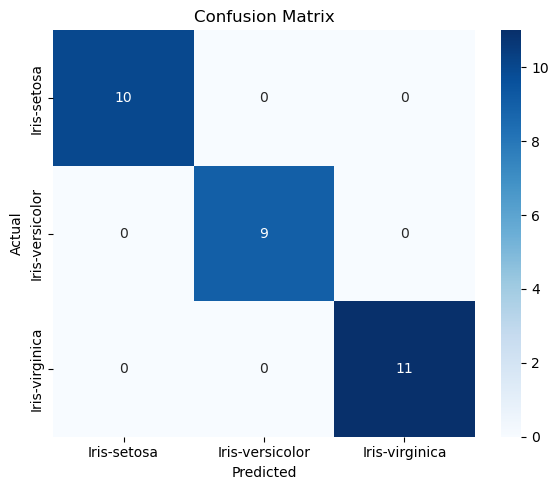

In [28]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=knn.classes_,
            yticklabels=knn.classes_)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.tight_layout()

plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

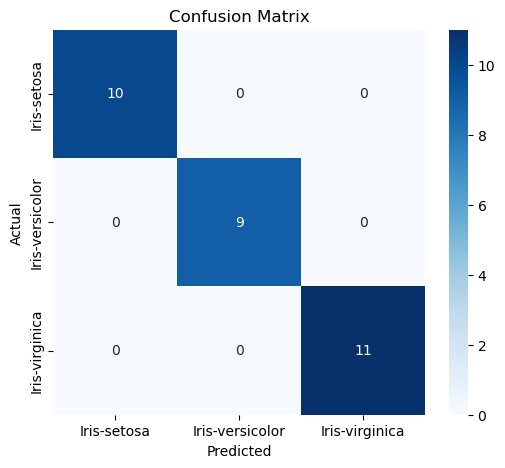

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=knn.classes_,
    yticklabels=knn.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

### Observation

The KNN classifier achieved a high accuracy on the test dataset, indicating that it learned the relationship between the flower measurements and species effectively. The confusion matrix shows that most flowers were classified correctly, with little or no misclassification between the three species. This demonstrates that the Iris dataset is well suited for classification using the KNN algorithm.

In [30]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      1.00      1.00         9
 Iris-virginica       1.00      1.00      1.00        11

       accuracy                           1.00        30
      macro avg       1.00      1.00      1.00        30
   weighted avg       1.00      1.00      1.00        30



### Observation

The classification report shows that the KNN model performed very well for all three Iris species. The precision, recall, and F1-score values are close to 1.0, indicating accurate and consistent predictions. This confirms that the model successfully learned the patterns in the flower measurements.

## Conclusion

In this project, the Iris flower dataset was successfully analyzed and used to build a machine learning classification model. The dataset was explored, cleaned, and visualized to understand the distribution and relationships between different flower measurements.

The data was divided into training and testing sets, and a K-Nearest Neighbors (KNN) classifier was trained to predict the species of Iris flowers based on their measurements. The model achieved high accuracy on the test data, demonstrating its ability to correctly classify unseen flower samples.

Overall, this project provided a practical understanding of the complete machine learning workflow, including data preprocessing, exploratory data analysis, model training, prediction, and performance evaluation.